# **Libraries**

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

# **Functions**

In [285]:
def quick_edit(x, y):
    from ipywidgets import interact, FloatSlider, IntSlider, VBox
    import plotly.graph_objects as go
    from IPython.display import display
    
    y_ed = y.copy()
    
    # Используем CSS для установки размера
    fig = go.FigureWidget()
    fig.add_scatter(x=x, y=y_ed, mode='lines+markers', marker=dict(size=8))
    
    # Устанавливаем размер через layout
    fig.layout.update(
        width=760,
        height=760,
        autosize=False
    )
    
    # Слайдеры
    idx_slider = IntSlider(min=0, max=len(x)-1, step=1, value=0, description='Index:')
    y_slider = FloatSlider(min=float(min(y) / 1.5), max=float(max(y) * 1.5), 
                          value=float(y[0]), step=(max(y)-min(y))/5000,
                          description='Y:', readout_format='.4f')
    
    def update(idx, val):
        y_ed[idx] = val
        fig.data[0].y = y_ed
    
    def on_click(trace, points, selector):
        if points.point_inds:
            idx = points.point_inds[0]
            idx_slider.value = idx
            y_slider.value = y_ed[idx]
    
    fig.data[0].on_click(on_click)
    
    display(fig)
    interact(update, idx=idx_slider, val=y_slider)
    
    return y_ed

def remove_peaks(y, min_width=10):
    peaks = find_peaks(y)[0]
    if len(peaks) == 0:
        return y
    
    widths = peak_widths(y, peaks, rel_height=0.5)[0]
    narrow_peaks = peaks[widths < min_width]
    
    y_clean = y.copy()
    for p in narrow_peaks:
        left = max(0, p - int(widths[peaks == p][0]) * 2)
        right = min(len(y), p + int(widths[peaks == p][0]) * 2)
        y_clean[left:right] = np.linspace(y[left], y[right], right - left)
    
    return y_clean

In [14]:
def Guinier(q, I_0, R_g):
    return I_0 * np.exp(-q ** 2 * R_g ** 2 / 3)

def norm_saxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>4)*(q<5)])
    #return q, I

    

def norm_waxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>20)*(q<20.5)])
    #return q, I

# **Data**

### for intagreation

In [15]:
poni_saxs = r"E:\Nps Cu\IHSC 1872\SAXS_1p4m_12keV.poni"
ai_saxs = pyFAI.load(poni_saxs)

poni_waxs = r"E:\Nps Cu\IHSC 1872\WAXS_1p4m_12keV.poni"
ai_waxs = pyFAI.load(poni_waxs)

mask_saxs = r"E:\Nps Cu\IHSC 1872\mask_akmal_saxs.edf"
img_mask_saxs = fabio.open(mask_saxs).data

mask_waxs = r"E:\Nps Cu\IHSC 1872\MASK_WAXS_1p4m_12keV.edf"
img_mask_waxs = fabio.open(mask_waxs).data

### Samples

In [16]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_05_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Isoth_190C_30min'
Cu_05_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_aftertrans\CuPE_0_5perc_1_4m_aftertrans_RT_measurement'
Cu_05_after = BM26_experiment(path)


In [17]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_3_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Isoth_190C'
Cu_3_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_aftertrans\CuPE_3perc_1_4m_aftertrans_RT_measurement'
Cu_3_after = BM26_experiment(path)

In [18]:
T_array_3 = Cu_3_heat.get_T_profile()
T_array_05 = Cu_05_heat.get_T_profile()

Found 89 EDF files in SAXS
Found 88 EDF files in SAXS


# **Figures**

### Fig1a: SAXS Curves

In [366]:
q, I_array_heat = Cu_3_heat.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_heat)
# px.scatter(Cu_05_heat.get_T_profile()
q, I_array_iso = Cu_3_iso.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_iso)

In [10]:
Time = Cu_05_iso.get_Time_profile()
Time[5] + 62

np.int64(231)

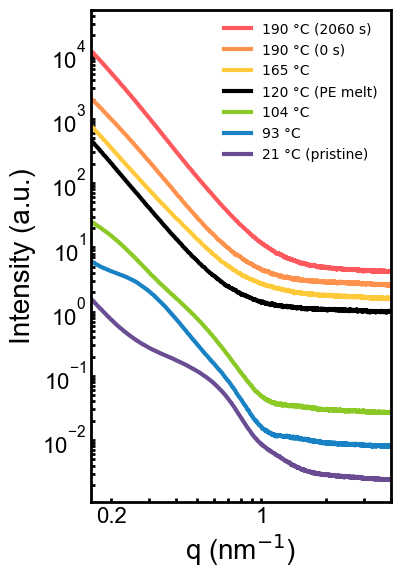

In [367]:
fig_a, ax_a = plt.subplots(figsize=(4, 6))

coef = 0.3
linewidth = 3

# Данные и параметры: (массив, сдвиг, цвет, метка)
plots_data_a = [
    (I_array_iso[-1], -1.2, '#ff595e', '190 °C (2060 s)'),
    (I_array_heat[-1], -0.8, '#ff924c', '190 °C (0 s)'),
    (I_array_heat[70], -0.4, '#ffca3a', '165 °C'),
    (I_array_heat[48], 0, 'black', '120 °C (PE melt)'),
    (I_array_heat[40], 3, '#8ac926', '104 °C'),
    (I_array_heat[35], 4, '#1982c4', '93 °C'),
    (I_array_heat[0], 5, '#6a4c93', '21 °C (pristine)')
]

for data, exp, color, label in plots_data_a:
    ax_a.loglog(q, data * coef ** exp, linewidth=linewidth, color=color, label=label)

ax_a.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax_a.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax_a.set_xlim(0.16, 4)
ax_a.set_ylim(1.1e-3, 5e4)
ax_a.set_xticks([0.2, 1])
ax_a.set_xticklabels(['0.2', '1'])

ax_a.legend(fontsize=10, frameon=False)
ax_a.tick_params(axis="both", which='both', direction="in", width=2, length=3, labelsize=16)

for axis in ['top','bottom','left','right']:
    ax_a.spines[axis].set_linewidth(2)

for tick in ax_a.get_xticklabels() + ax_a.get_yticklabels():
    tick.set_fontfamily('Arial')

# Устанавливаем положение осей: bottom = 0.12, height = 0.82
ax_a.set_position([0.15, 0.12, 0.75, 0.82])

plt.savefig(r'E:\Nps Cu\Figures v2\Fig1_a.png', dpi=300, bbox_inches='tight', transparent=True)
# plt.close(fig_a)

### Fig1b: WAXS curves

In [368]:
q, I_array_heat = Cu_3_heat.integrate1d_WAXS(ai_waxs, 10000, mask = img_mask_waxs)
# norm_saxs(q, I_array_heat)

q, I_array_iso = Cu_3_iso.integrate1d_WAXS(ai_waxs, 10000, mask = img_mask_waxs)
# norm_saxs(q, I_array_iso)
theta_111 = np.array([43.34, 38.86, 36.33]) /2

q_111 = 4 * pi * np.sin(np.deg2rad(theta_111)) / 0.15406 

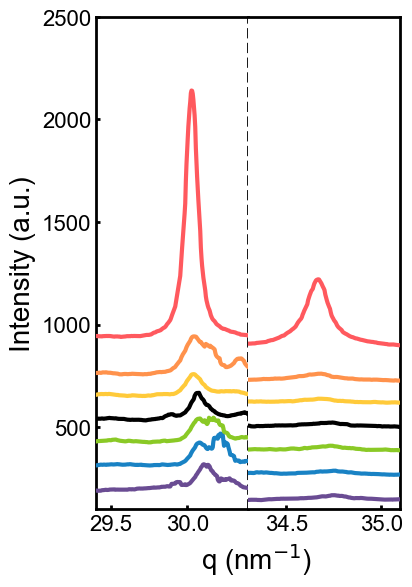

In [372]:
fig_b, (ax1, ax2) = plt.subplots(1, 2, figsize=(4, 6), sharey=True)

K = 120
linewidth = 3

plots_data_b = [
    (I_array_iso[-1], 6, '#ff595e', '190 °C (2060 s)', 10),
    (I_array_iso[1], 5, '#ff924c', '190 °C (0 s)', 9),
    (I_array_heat[70], 4, '#ffca3a', '165 °C', 8),
    (I_array_heat[49], 3, 'black', '120 °C (PE melt)', 7),
    (I_array_heat[41], 2, '#8ac926', '104 °C', 6),
    (I_array_heat[35], 1, '#1982c4', '93 °C', 5),
    (I_array_heat[12], 0, '#6a4c93', '21 °C (pristine)', 3)
]

xlims = [(29.4, 30.4), (34.3, 35.1)]

for ax, xlim in zip([ax1, ax2], xlims):
    for data, offset, color, label, zorder in plots_data_b:
        ax.plot(q, data + K * offset, linewidth=linewidth, color=color, label=label, zorder=zorder)
    
    ax.set_xlim(xlim)
    ax.set_ylim(100, 2500)
    
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    
    ax.tick_params(axis="both", which='both', direction="in", width=2, length=3, labelsize=16)
    
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial')

ax1.set_ylabel('Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax2.set_ylabel('')

# Убираем y-тики на втором графике
ax2.tick_params(axis='y', left=False, labelleft=False)

# Убираем внутренние границы и склеиваем
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Вертикальная линия на первом графике
ax1.axvline(x=30.4, color='black', linewidth=2, linestyle='--')

# Общая подпись оси x
fig_b.text(0.5, 0.02, r'q (nm$^{-1}$)', ha='center', fontsize=20, fontfamily='Arial')

# Склеиваем сабплоты
plt.subplots_adjust(wspace=0)

# Устанавливаем положение осей с теми же bottom и height, что и у графика a
# left и width подбираем для двух сабплотов
ax1.set_position([0.10, 0.12, 0.38, 0.82])
ax2.set_position([0.48, 0.12, 0.38, 0.82])

plt.savefig(r'E:\Nps Cu\Figures v2\Fig1_b.png', dpi=300, bbox_inches='tight', transparent=True)
# plt.close(fig_b)

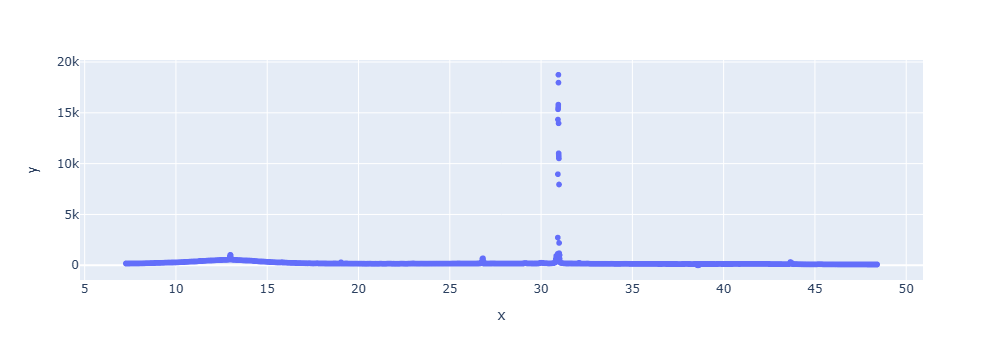

In [14]:
px.scatter(x=q, y=I_array_iso[0])

### Fig2a: SAXS after bkg subraction

In [275]:
import scipy
def Spheres(x, scale, Ravg, p, bkg):
    global sigma
    sigma = p*Ravg
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2)
        Iq.append(scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1])
    Iq = np.array(Iq)
    Iq /= max(Iq)
    return scale * Iq + bkg

In [362]:
q, I_array_heat = Cu_05_heat.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_heat)
# px.scatter(Cu_05_heat.get_T_profile()
q, I_array_iso = Cu_05_iso.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_iso)

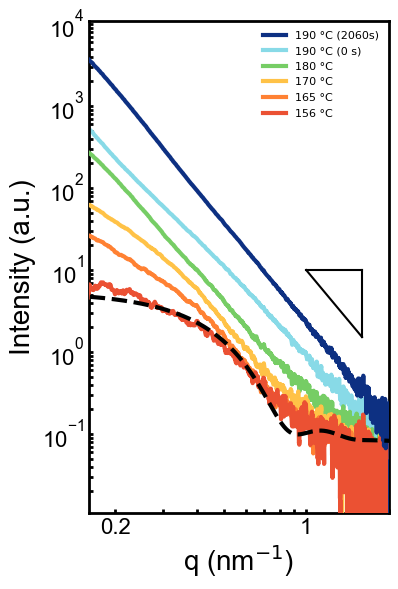

In [363]:
fig_a, ax_a = plt.subplots(figsize=(4, 6))

coef = 1.2
linewidth = 3

bkg = I_array_heat[45]
# Данные и параметры: (массив, сдвиг, цвет, метка)
plots_data_a = [

    (I_array_iso[-1] - 1 * bkg, 5, '#0d3082', '190 °C (2060s)', 10, 3),
    (I_array_heat[82] - 1 * bkg, 4, '#88dae7', '190 °C (0 s)', 2, 3),
    (I_array_heat[77] - 1 * bkg, 3, '#76cd65', '180 °C', 3, 3),
    # (I_array_heat[74] - 1 * bkg, 3, '#f29222', '174 °C', 4, 3),
    (I_array_heat[72] - 1 * bkg, 2, '#ffc247', '170 °C', 5, 3),
    (I_array_heat[70] - 1 * bkg, 1, '#ff8133', '165 °C', 6, 3),
    (I_array_heat[65] + I_array_heat[66] - 2 * bkg, 0, '#eb5133', '156 °C', 6, 3),
]

for data, exp, color, label, zorder, linewidth in plots_data_a:
    ax_a.loglog(q, data * coef ** exp , linewidth=linewidth, color=color, label=label, zorder=zorder)

ax_a.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax_a.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax_a.set_xlim(0.16, 2)
ax_a.set_ylim(1.1e-2, 1.1e4)
ax_a.set_xticks([0.2, 1])
ax_a.set_xticklabels(['0.2', '1'])

ax_a.legend(fontsize=8, frameon=False)
ax_a.tick_params(axis="both", which='both', direction="in", width=2, length=3, labelsize=16)

for axis in ['top','bottom','left','right']:
    ax_a.spines[axis].set_linewidth(2)

for tick in ax_a.get_xticklabels() + ax_a.get_yticklabels():
    tick.set_fontfamily('Arial')

# Устанавливаем положение осей: bottom = 0.12, height = 0.82
ax_a.set_position([0.15, 0.12, 0.75, 0.82])


plt.plot(q, Spheres(q, 5, 4.8, 0.11, 0.8e-1), color='black', label='Form-factor', linewidth=3, linestyle='--', zorder=30)

x_porod = np.linspace(1.0, 1.6, 1000)
y_porod = x_porod ** -4
y_porod /= max(y_porod)
A = 1e1
plt.plot(x_porod, y_porod * A, color='black', )
plt.plot(x_porod, A * np.ones(1000), color='black', )
plt.plot(np.ones(1000)*max(x_porod), y_porod * A, color='black', )



plt.savefig(r'E:\Nps Cu\Figures v2\Fig2_a.png', dpi=300, bbox_inches='tight', transparent=True)
# plt.close(fig_a)

### Fig2bc: Rg

In [270]:
df = pd.DataFrame({'fr_05':range(len(new_R_g_05)), 'Rg_05':new_R_g_05})
df.to_csv(r'E:\Nps Cu\Figures v2\Rg05.txt', sep='\t', index=False)

df = pd.DataFrame({'fr_05':range(len(new_R_g_3)), 'Rg_05':new_R_g_3})
df.to_csv(r'E:\Nps Cu\Figures v2\Rg3.txt', sep='\t', index=False)


Found 89 EDF files in SAXS
Found 88 EDF files in SAXS


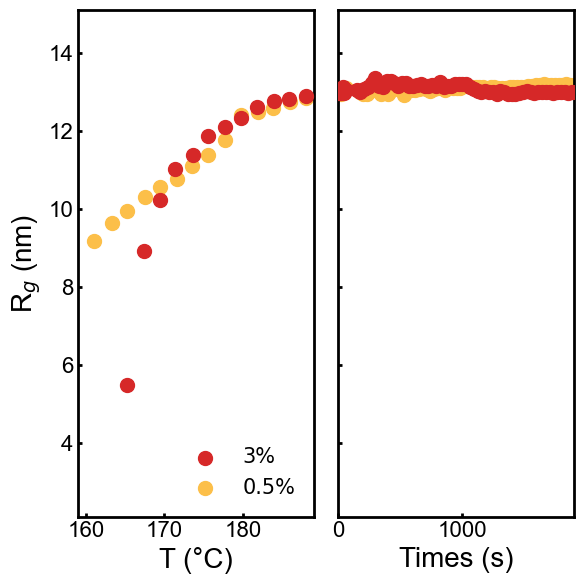

In [373]:
# Создаем фигуру с двумя сабплотами рядом и общей осью Y
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 6), sharey=True)
size = 100
color3 = '#d62828'
color05 = '#fcbf49'
alpha = 1

# ==================== ЛЕВЫЙ ГРАФИК ====================
ax1.scatter(Cu_3_heat.get_T_profile()[71:83], new_R_g_3[:12], color=color3, s=size, label='3%', alpha=alpha, zorder=10)
ax1.scatter(Cu_05_heat.get_T_profile()[68:82], new_R_g_05[:14], color=color05, s=size, label='0.5%', alpha=alpha)

ax1.set_xlabel(r'T (°C)', fontsize=20, fontfamily='Arial')
ax1.set_ylabel(r'R$_g$ (nm)', fontsize=20, fontfamily='Arial')
ax1.set_ylim(2.1, 15.1)
ax1.set_xlim(159, 189)

ax1.legend(fontsize=8, frameon=False)
ax1.tick_params(axis="both", which='both', direction="in", width=2, length=3, labelsize=16)

for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(2)

for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontfamily('Arial')

# ==================== ПРАВЫЙ ГРАФИК ====================
Time_05 = 174 + Cu_05_iso.get_Time_profile()
Time_05_iso = Cu_05_heat.get_Time_profile()[82:] - Cu_05_heat.get_Time_profile()[82]
Time_3 = 149 + Cu_3_iso.get_Time_profile()
Time_3_iso = Cu_05_heat.get_Time_profile()[82:] - Cu_05_heat.get_Time_profile()[82]


ax2.scatter(Time_3_iso, new_R_g_3[12:12+len(Time_3_iso)] , color=color3, s=size, alpha=alpha, zorder=10)
ax2.scatter(Time_05_iso, new_R_g_05[14:14+len(Time_05_iso)] , color=color05, s=size, alpha=alpha)

ax2.scatter(Time_05, new_R_g_05[(14+len(Time_05_iso)):] , color=color05, s=size, alpha=alpha)
ax2.scatter(Time_3, new_R_g_3[(13+len(Time_3_iso)):] , color=color3, s=size, alpha=alpha, zorder=10)


ax2.set_xlabel(r'Times (s)', fontsize=20, fontfamily='Arial')
# ax2.set_ylabel(r'R$_g$ (nm)', fontsize=20, fontfamily='Arial')  # Закомментировано из-за sharey=True
ax2.set_xlim(-0.1, 1900)

ax1.legend(fontsize=15, loc=4, frameon=False)
ax2.tick_params(axis="both", which='both', direction="in", width=2, length=3, labelsize=16)

for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(2)

for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontfamily('Arial')

# Настройка отступов (опционально)
plt.tight_layout()

# Сохраняем фигуру
plt.savefig(r'E:\Nps Cu\Figures v2\Fig2_combined.png', dpi=300, bbox_inches='tight', transparent=True)
# plt.close(fig)

### Fig3: Invariant and 111 peak

In [428]:
q, I_array_heat = Cu_05_heat.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_heat)

q, I_array_iso = Cu_05_iso.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_iso)

In [429]:
inv_05 = []

bkg = I_array_heat[45]

for i in range(62, len(I_array_heat)):
    x = q
    y = I_array_heat[i] - 0.96 * bkg
    
    l, r = 0.16, 1
    X = x[(x>l)*(x<r)]
    Y = y[(x>l)*(x<r)] * X ** 2
    
    inv_05.append(np.trapezoid(Y, x=X))

for i in range(len(I_array_iso)):
    x = q
    y = I_array_iso[i] - 0.96 * bkg
    
    l, r = 0.16, 1
    X = x[(x>l)*(x<r)]
    Y = y[(x>l)*(x<r)] * X ** 2
    
    inv_05.append(np.trapezoid(Y, x=X))

In [286]:
new_inv_05 = quick_edit(np.arange(len(inv_05)), inv_05)

FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': 'fe02fbb9-787b-4658-bfc2-0c156e300ed7',
              'x': {'bdata': ('AAECAwQFBgcICQoLDA0ODxAREhMUFR' ... 'ZHSElKS0xNTk9QUVJTVFVWV1hZWls='),
                    'dtype': 'i1'},
              'y': [0.061860370185848494, 0.07810520681937094,
                    0.09482156851091529, 0.11537957222765936, 0.13650908653402274,
                    0.16202764739421832, 0.19727301670220865, 0.235705697781165,
                    0.28059389330892764, 0.33762749873600034, 0.40744790205201137,
                    0.4813258586963882, 0.5583267964643042, 0.626422077036399,
                    0.6931419610595448, 0.7323701736405682, 0.766724118742538,
                    0.8057805260831459, 0.8702088631673106, 1.0247843575462752,
                    1.335154632495652, 1.781337023388828, 2.3129566512184825,
                    2.8364212858495392, 3.487049784

interactive(children=(IntSlider(value=0, description='Index:', max=91), FloatSlider(value=0.061860370185848494…

In [288]:
q, I_array_heat = Cu_3_heat.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_heat)
# px.scatter(Cu_05_heat.get_T_profile()
q, I_array_iso = Cu_3_iso.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_iso)

In [289]:
inv_3 = []

bkg = I_array_heat[45]

for i in range(62, len(I_array_heat)):
    x = q
    y = I_array_heat[i] - 0.96 * bkg

    l, r = 0.16, 1
    X = x[(x>l)*(x<r)]
    Y = y[(x>l)*(x<r)] * X ** 2

    inv_3.append(np.trapezoid(Y, x=X))

for i in range(len(I_array_iso)):
    x = q
    y = I_array_iso[i] - 0.96 * bkg

    l, r = 0.16, 1
    X = x[(x>l)*(x<r)]
    Y = y[(x>l)*(x<r)] * X ** 2

    inv_3.append(np.trapezoid(Y, x=X))
    

In [290]:
new_inv_3 = quick_edit(np.arange(len(inv_3)), inv_3)

FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '8925f552-ada4-43f7-b554-cb5e4e3aec68',
              'x': {'bdata': ('AAECAwQFBgcICQoLDA0ODxAREhMUFR' ... 'BBQkNERUZHSElKS0xNTk9QUVJTVFVW'),
                    'dtype': 'i1'},
              'y': [-0.02906707947908694, 0.002769380432662727,
                    0.02694586972828808, 0.07128664687258437, 0.10853667529897512,
                    0.1521061683492757, 0.21682698764689717, 0.30946803892120067,
                    0.4112807650104252, 0.5159700104350369, 0.6583483035025927,
                    0.8306087733602148, 1.007376507367912, 1.2287166104137848,
                    1.4677448108390228, 1.7625294227648904, 1.9115946744155967,
                    2.1093927108009787, 2.2245784522316763, 2.0935930296109397,
                    1.9875619351175624, 2.1512947486378042, 2.0922094289122137,
                    1.8666781305750282, 1.3695453

interactive(children=(IntSlider(value=0, description='Index:', max=86), FloatSlider(value=-0.01937805298605796…

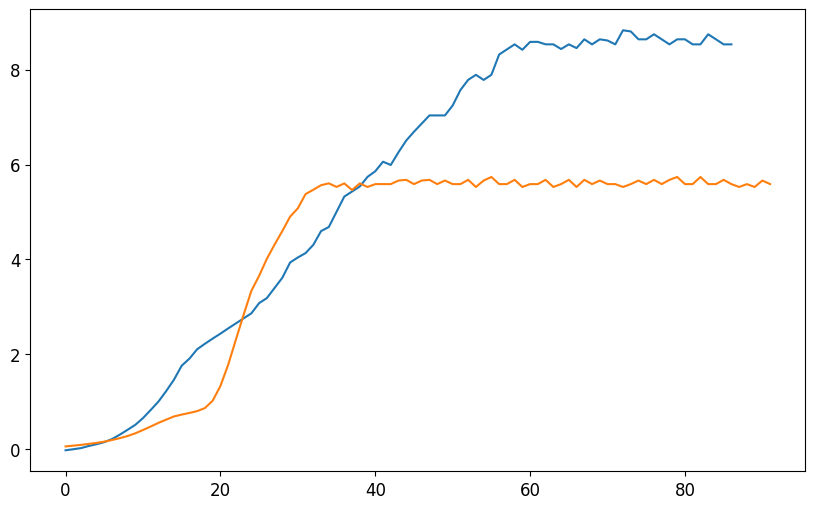

In [291]:
plt.plot(new_inv_3)
plt.plot(new_inv_05)

In [292]:
df = pd.DataFrame({'fr_05':range(len(new_inv_3)), 'Rg_05':new_inv_3})
df.to_csv(r'E:\Nps Cu\Figures v2\inv3.txt', sep='\t', index=False)

df = pd.DataFrame({'fr_05':range(len(new_inv_05)), 'Rg_05':new_inv_05})
df.to_csv(r'E:\Nps Cu\Figures v2\inv05.txt', sep='\t', index=False)

### Fig3: Peak 111

In [313]:
def norm_waxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>20)*(q<20.5)])

In [332]:
q, I_array_heat = Cu_05_heat.integrate1d_WAXS(ai_waxs, 1000, mask = img_mask_waxs)
norm_waxs(q, I_array_heat)

q, I_array_iso = Cu_05_iso.integrate1d_WAXS(ai_waxs, 1000, mask = img_mask_waxs)
norm_waxs(q, I_array_iso)

In [337]:
I_111_05 = []

for i in range(62, 88):
    I_111_05.append(I_array_heat[i][553])

for i in range(66):
    I_111_05.append(I_array_iso[i][553])    


In [341]:
new_I_111_05 = quick_edit(np.arange(len(I_111_05)), I_111_05)

FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '82614739-7eaf-41e6-a268-24c9ebcd01ad',
              'x': {'bdata': ('AAECAwQFBgcICQoLDA0ODxAREhMUFR' ... 'ZHSElKS0xNTk9QUVJTVFVWV1hZWls='),
                    'dtype': 'i1'},
              'y': [1.3717751502990723, 1.235617756843567, 1.2225189208984375,
                    1.317622184753418, 1.2184338569641113, 1.2224812507629395,
                    1.2258328199386597, 1.2493183612823486, 1.240494728088379,
                    1.2337614297866821, 1.250868320465088, 1.2444179058074951,
                    1.2389990091323853, 1.2440513372421265, 1.234690546989441,
                    1.2483760118484497, 1.2432490587234497, 1.2662525177001953,
                    1.269162893295288, 1.296889305114746, 1.3240200281143188,
                    1.3659380674362183, 1.3818449974060059, 1.435294270515442,
                    1.4705922603607178, 1.542

interactive(children=(IntSlider(value=0, description='Index:', max=91), FloatSlider(value=1.3717751502990723, …

In [342]:
q, I_array_heat = Cu_3_heat.integrate1d_WAXS(ai_waxs, 1000, mask = img_mask_waxs)
norm_waxs(q, I_array_heat)

q, I_array_iso = Cu_3_iso.integrate1d_WAXS(ai_waxs, 1000, mask = img_mask_waxs)
norm_waxs(q, I_array_iso)

In [344]:
I_111_3 = []

for i in range(89):
    I_111_3.append(I_array_heat[i][553])

for i in range(60):
    I_111_3.append(I_array_iso[i][553])    

In [346]:
df = pd.DataFrame({'fr_05':range(len(new_I_111_3)), 'Rg_05':new_I_111_3})
df.to_csv(r'E:\Nps Cu\Figures v2\i_111_3.txt', sep='\t', index=False)

df = pd.DataFrame({'fr_05':range(len(new_I_111_05)), 'Rg_05':new_I_111_05})
df.to_csv(r'E:\Nps Cu\Figures v2\i_111_05.txt', sep='\t', index=False)

In [345]:
new_I_111_3 = quick_edit(np.arange(len(I_111_3)), I_111_3)

FigureWidget({
    'data': [{'marker': {'size': 8},
              'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '2d53f54c-03af-4db4-b16f-a2be15f33a18',
              'x': {'bdata': ('AAABAAIAAwAEAAUABgAHAAgACQAKAA' ... 'CLAIwAjQCOAI8AkACRAJIAkwCUAA=='),
                    'dtype': 'i2'},
              'y': [1.567574381828308, 1.5673935413360596, 1.5651367902755737,
                    1.5566275119781494, 1.5599783658981323, 1.563058614730835,
                    1.5569508075714111, 1.5500470399856567, 1.5609441995620728,
                    1.5568279027938843, 1.553109884262085, 1.5585623979568481,
                    1.5534807443618774, 1.5578207969665527, 1.562484860420227,
                    1.5537545680999756, 1.5600414276123047, 1.5562896728515625,
                    1.5649081468582153, 1.580273151397705, 1.5792782306671143,
                    1.577089548110962, 1.5898360013961792, 1.5765341520309448,
                    1.5812156200408936, 1.5

interactive(children=(IntSlider(value=0, description='Index:', max=148), FloatSlider(value=1.567574381828308, …

In [424]:
len(Time_05_iso)

6

60
68


ValueError: x and y must be the same size

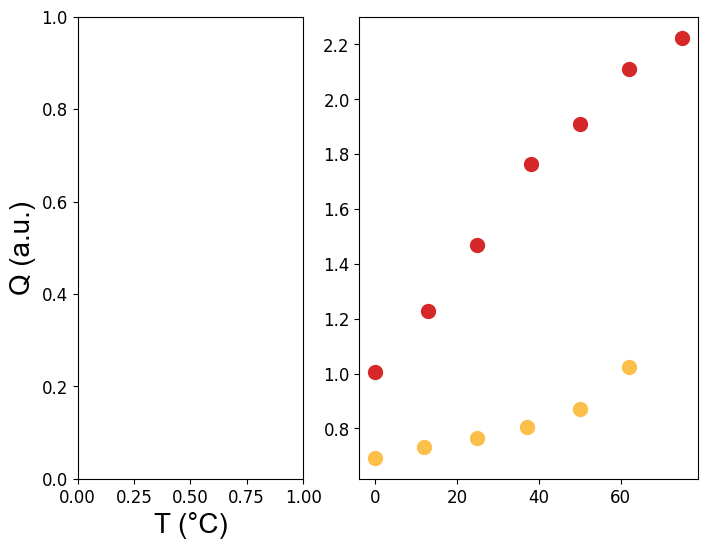

In [427]:
# Создаем фигуру с двумя сабплотами (правый шире)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6), gridspec_kw={'width_ratios': [1, 1.5]})

size = 100
color3 = '#d62828'
color05 = '#fcbf49'
alpha = 1

# ==================== ЛЕВЫЙ ГРАФИК (Rg) ====================
ax1.set_xlabel(r'T (°C)', fontsize=20, fontfamily='Arial')
ax1.set_ylabel(r'Q (a.u.)', fontsize=20, fontfamily='Arial')

Time_05 = 174 + Cu_05_iso.get_Time_profile()
Time_05_iso = Cu_05_heat.get_Time_profile()[82:] - Cu_05_heat.get_Time_profile()[82]
Time_3 = 149 + Cu_3_iso.get_Time_profile()
Time_3_iso = Cu_3_heat.get_Time_profile()[82:] - Cu_3_heat.get_Time_profile()[82]


ax2.scatter(Time_3_iso, inv_3[12:12+len(Time_3_iso)] , color=color3, s=size, alpha=alpha, zorder=10)
ax2.scatter(Time_05_iso, inv_05[14:14+len(Time_05_iso)] , color=color05, s=size, alpha=alpha)

print(len(Time_3))
print(len(inv_3[(12+len(Time_3_iso)):]))
ax2.scatter(Time_3, inv_3[(12+len(Time_3_iso)):] , color=color3, s=size, alpha=alpha, zorder=10)
ax2.scatter(Time_05, inv_05[(14+len(Time_05_iso)):] , color=color05, s=size, alpha=alpha)


ax1.tick_params(axis="both", which='both', direction="in", width=2, length=3, labelsize=16)

for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(2)

for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontfamily('Arial')

# ==================== ПРАВЫЙ ГРАФИК (I_111) ====================
ax2.set_xlabel(r'Time (s)', fontsize=20, fontfamily='Arial')
ax2.set_ylabel(r'I$_{111}$ (a.u.)', fontsize=20, fontfamily='Arial')
# ax2.set_xlim(-0.1, 1900)

ax2.tick_params(axis="both", which='both', direction="in", width=2, length=3, labelsize=16)

# Ось I_111 СПРАВА
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()

for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(2)

for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
    tick.set_fontfamily('Arial')

plt.tight_layout()

In [391]:
new_I_111_3 = new_I_111_3[62:]